In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [22]:
data = [
    #Arf_side_peak_V #Fund_25M_V
    [1e-3, 13.35e-3],
    [5e-3, 66.8e-3],
    [10e-3, 133.5e-3],
    [15e-3, 200e-3],
    [20e-3, 266.5e-3],
    [25e-3, 332.7e-3],
    [30e-3, 398.5e-3],
    [35e-3, 463.5e-3],
    [40e-3, 528e-3],
    [45e-3, 592e-3],
    [50e-3, 655e-3],
    [55e-3, 716.5e-3],
    [60e-3, 777.2e-3],
    [65e-3, 836e-3],
    [70e-3, 892.5e-3],
    [75e-3, 946.5e-3],
    [80e-3, 996.4e-3],
    [85e-3, 1.04],
    [90e-3, 1.082],
    [95e-3, 1.118],
    [100e-3, 1.15]
]
df= pd.DataFrame(data, columns=["Arf_side_peak_V", "Fund_25M_V"])
df

,Arf_side_peak_V,Fund_25M_V
0,0.001,0.01335
1,0.005,0.06680
2,0.010,0.13350
3,0.015,0.20000
4,0.020,0.26650
5,0.025,0.33270
6,0.030,0.39850
7,0.035,0.46350
8,0.040,0.52800
9,0.045,0.59200


In [24]:
Rdiff = 50 #differential input resistance

#input voltage
df["Vin_diff_peak_V"] = 2*df["Arf_side_peak_V"]
df["Vin_diff_rms_V"] = df["Vin_diff_peak_V"]/np.sqrt(2)

#input power
df["Pin_W"] = df["Vin_diff_rms_V"]**2/Rdiff
df["Pin_dBm"] = 10*np.log10(df["Pin_W"]/1e-3)

#output voltage
df["Vout_peak_dBV"] = 20*np.log10(df["Fund_25M_V"])

#gain
df["Vin_peak_dBV"] = 20*np.log10(df["Vin_diff_peak_V"])
df["Gain_dB"] = df["Vout_peak_dBV"] - df["Vin_peak_dBV"]

In [31]:
linear_df = df.iloc[:6].copy()
small_signal_gain_dB = linear_df["Gain_dB"].mean()
print(f"Small-signal conversion gain = {small_signal_gain_dB:.2f} dB")

Small-signal conversion gain = 16.48 dB


In [26]:
df["Compression_dB"] = small_signal_gain_dB - df["Gain_dB"]
df

,Arf_side_peak_V,Fund_25M_V,Vin_diff_peak_V,Vin_diff_rms_V,Pin_W,Pin_dBm,Vout_peak_dBV,Vin_peak_dBV,Gain_dB,Compression_dB
0,0.001,0.01335,0.002,0.001414,4.000000e-08,-43.979400,-37.490375,-53.979400,16.489025,-0.008000
1,0.005,0.06680,0.010,0.007071,1.000000e-06,-30.000000,-23.504471,-40.000000,16.495529,-0.014503
2,0.010,0.13350,0.020,0.014142,4.000000e-06,-23.979400,-17.490375,-33.979400,16.489025,-0.008000
3,0.015,0.20000,0.030,0.021213,9.000000e-06,-20.457575,-13.979400,-30.457575,16.478175,0.002851
4,0.020,0.26650,0.040,0.028284,1.600000e-05,-17.958800,-11.486056,-27.958800,16.472744,0.008281
5,0.025,0.33270,0.050,0.035355,2.500000e-05,-16.020600,-9.558944,-26.020600,16.461656,0.019370
6,0.030,0.39850,0.060,0.042426,3.600000e-05,-14.436975,-7.991433,-24.436975,16.445542,0.035484
7,0.035,0.46350,0.070,0.049497,4.900000e-05,-13.098039,-6.679005,-23.098039,16.419034,0.061992
8,0.040,0.52800,0.080,0.056569,6.400000e-05,-11.938200,-5.547322,-21.938200,16.390879,0.090147
9,0.045,0.59200,0.090,0.063640,8.100000e-05,-10.915150,-4.553566,-20.915150,16.361584,0.119442


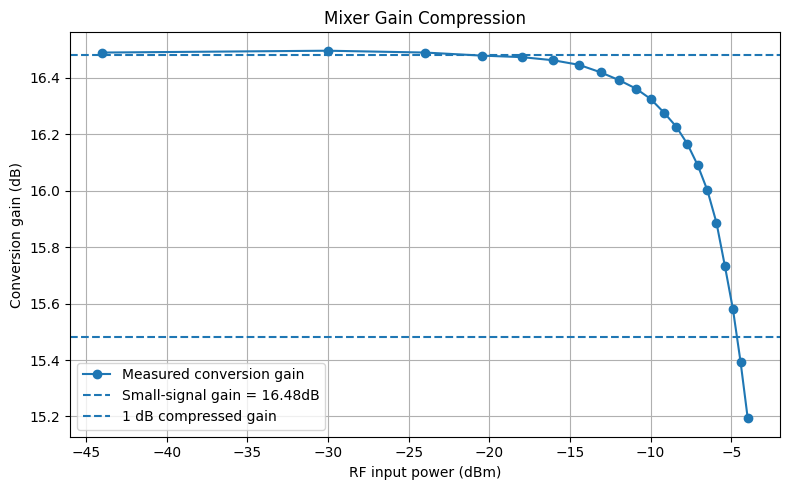

In [29]:
plt.figure(figsize = (8,5))
plt.plot(df["Pin_dBm"],
         df["Gain_dB"],
         marker = "o",
         label="Measured conversion gain"
        )

plt.axhline(small_signal_gain_dB,
            linestyle = "--",
            label=f"Small-signal gain = {small_signal_gain_dB:.2f}dB"
           )

plt.axhline(small_signal_gain_dB-1,
            linestyle="--",
            label="1 dB compressed gain"
           )

plt.xlabel("RF input power (dBm)")
plt.ylabel("Conversion gain (dB)")
plt.title("Mixer Gain Compression")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("p1db.png")
plt.show()

In [30]:
idx_high = df.index[df["Compression_dB"] >= 1][0]
idx_low = idx_high - 1

x1 = df.loc[idx_low, "Pin_dBm"]
x2 = df.loc[idx_high, "Pin_dBm"]

c1 = df.loc[idx_low, "Compression_dB"]
c2 = df.loc[idx_high, "Compression_dB"]

p1db_dBm = x1 + (1 - c1) * (x2 - x1) / (c2 - c1)

print(f"Input P1dB = {p1db_dBm:.2f} dBm")

Input P1dB = -4.65 dBm
